# Procedimiento de Unificación de los datos
A continuación se detalla el proceso para la unificación de los datos públicos de Fonasa:



## 1. Corregir Archivo 2024

Al visualizar cada archivo de forma manual, notamos que el archivo **'GRD_PUBLICO_2024.txt'** presenta un **error de inconsistencia/corrupción de codificación** que afectó la integridad estructural del archivo CSV. Por este motivo, primero se lee el archivo para decodificarlo al tipo de archivo esperado para unificar los datos.

In [ ]:
import os
def corregir_codificacion(archivo_original, archivo_corregido):
    """
    Lee un archivo en modo binario, lo decodifica y elimina las líneas en blanco
    adicionales, guardando el resultado en un nuevo archivo.
    """
    print(f"Corrigiendo la codificación de '{archivo_original}'...")
    
    try:
        # Abrimos el archivo original en modo binario para leer los bytes crudos
        with open(archivo_original, 'rb') as f_in:
            contenido_bytes = f_in.read()

        # Se debe decodificar los bytes usando una codificación tolerante
        contenido_decodificado = contenido_bytes.decode('latin-1', errors='replace')
        
        # Eliminamos las líneas en blanco adicionales reemplazando el doble salto por uno solo
        contenido_sin_lineas_extra = contenido_decodificado.replace('\r\n', '\n').replace('\n\n', '\n')
        
        # Guardar el nuevo archivo de texto
        with open(archivo_corregido, 'w', encoding='utf-8') as f_out:
            f_out.write(contenido_sin_lineas_extra)

        print(f"Archivo corregido y sin líneas en blanco guardado en: {archivo_corregido}")
        
    except FileNotFoundError:
        print(f"Error: El archivo '{archivo_original}' no fue encontrado.")
    except Exception as e:
        print(f"Error inesperado al corregir el archivo: {str(e)}")

# Correción del archivo
archivo_original = '../0_data_raw/GRD_Year/GRD_PUBLICO_2024.txt'
archivo_corregido = '../0_data_raw/GRD_Year/GRD_PUBLICO_2024_corregido.txt'

if os.path.exists(archivo_original):
    corregir_codificacion(archivo_original, archivo_corregido)
else:
    print(f"El archivo '{archivo_original}' no existe en la carpeta '0_data_raw'.")

Corrigiendo la codificación de '../0_data_raw/GRD_Year/GRD_PUBLICO_2024.txt'...
Archivo corregido y sin líneas en blanco guardado en: ../0_data_raw/GRD_Year/GRD_PUBLICO_2024_corregido.txt


## 2.Verificar Archivo Corregido
Una vez el archivo ha sido corregido y creado una nueva versión nos encargamos de verificar si ha sido exitoso.

In [ ]:
def verificar_archivo_corregido(archivo_path):
    """
    Verifica la estructura de un archivo, contando filas y mostrando un fragmento.
    """
    print(f"Analizando la estructura de '{archivo_path}'...")
    try:
        with open(archivo_path, 'r', encoding='utf-8') as f:
            lineas = f.readlines()
            
            num_filas = len(lineas)
            
            # Verificamos el número de filas
            print(f"El archivo tiene un total de {num_filas:,} filas.")

            if num_filas > 0:
                # Verificamos el encabezado (la primera línea)
                encabezado = lineas[0].strip()
                if '|' in encabezado and len(encabezado.split('|')) > 100:
                    print(f"La primera fila tiene {len(encabezado.split('|'))} columnas.")
                else:
                    print("Encabezado inválido.")
                
                # Mostramos las primeras 500 filas
                print("\n--- Primeras 500 filas ---")
                for i in range(min(500, len(lineas))):
                    print(lineas[i].strip())
                
                # Mostramos las últimas 500 filas (para ver las vacías al final)
                if num_filas > 500:
                    print("\n--- Últimas 500 filas ---")
                    for i in range(max(0, num_filas - 500), num_filas):
                        print(lineas[i].strip())
            else:
                print("El archivo está vacío.")
    
    except FileNotFoundError:
        print(f"Error: El archivo '{archivo_path}' no fue encontrado.")
    except Exception as e:
        print(f"Error leyendo el archivo: {str(e)}")

# Ejecutar la función
verificar_archivo_corregido('../0_data_raw/GRD_Year/GRD_PUBLICO_2024_corregido.txt')

Analizando la estructura de '../0_data_raw/GRD_Year/GRD_PUBLICO_2024_corregido.txt'...
El archivo tiene un total de 1,085,814 filas.
La primera fila parece ser un encabezado válido con 129 columnas.

--- Primeras 500 filas ---
COD_HOSPITAL|ID_BENEFICIARIO|SEXO|FECHA_NACIMIENTO|ETNIA|PROVINCIA|COMUNA|NACIONALIDAD|PREVISION|SERVICIO_SALUD|TIPO_PROCEDENCIA|TIPO_INGRESO|ESPECIALIDAD_MEDICA|TIPO_ACTIVIDAD|FECHA_INGRESO|SERVICIOINGRESO|FECHATRASLADO1|SERVICIOTRASLADO1|FECHATRASLADO2|SERVICIOTRASLADO2|FECHATRASLADO3|SERVICIOTRASLADO3|FECHATRASLADO4|SERVICIOTRASLADO4|FECHATRASLADO5|SERVICIOTRASLADO5|FECHATRASLADO6|SERVICIOTRASLADO6|FECHATRASLADO7|SERVICIOTRASLADO7|FECHATRASLADO8|SERVICIOTRASLADO8|FECHATRASLADO9|SERVICIOTRASLADO9|FECHAALTA|SERVICIOALTA|TIPOALTA|CONDICIONDEALTANEONATO1|PESORN1|SEXORN1|RN1ESTADO|CONDICIONDEALTANEONATO2|PESORN2|SEXORN2|RN2ESTADO|CONDICIONDEALTANEONATO3|PESORN3|SEXORN3|RN3ESTADO|CONDICIONDEALTANEONATO4|PESORN4|SEXORN4|RN4ESTADO|DIAGNOSTICO1|DIAGNOSTICO2|DIAGNOSTICO

## 3. Unificación
Con el archivo corregido, podemos ejecutar el script que se encarga de unificar todos los datos:
- Algunos archivos presentan problemas para utilizar encoding 'utf-8' y debe ser reemplazado por 'utf-16'. La apertura del archivo se maneja según su codificación.
- Primero se abre el documento que acaba de ser corregido en caso de que presente errores y no deba esperar a que los archivos de años anteriores sean procesados para reportar el error.
- Consideramos que ID_BENEFICIARIO será la columna final siguiendo al archivo del año 2024, ya que los anteriores ocupan el nombre de CIP_ENCRIPTADO para identificar al paciente.

In [ ]:
import os
import pandas as pd
from datetime import datetime

COLUMNA_ID_UNIFICADA = 'ID_BENEFICIARIO' # Nombre que usaremos para el ID unificado
COLUMNA_ID_ANTERIOR = 'CIP_ENCRIPTADO' # Nombre que usaban los archivos antiguos de 2024


def procesar_archivo(año, archivo_path, encoding):
    """
    Función para procesar un solo archivo con su codificación específica.
    """
    try:
        print(f"Leyendo: {os.path.basename(archivo_path)} (Año {año})...")
        df_temp = pd.read_csv(
            archivo_path,
            sep='|',
            encoding=encoding,
            on_bad_lines='skip',
            engine='python',
            quoting=3
        )
        
        #Renombrar la columna de ID si es necesario
        if año != 2024 and COLUMNA_ID_ANTERIOR in df_temp.columns:
            df_temp.rename(columns={COLUMNA_ID_ANTERIOR: COLUMNA_ID_UNIFICADA}, inplace=True)
            print(f"Columna '{COLUMNA_ID_ANTERIOR}' renombrada a '{COLUMNA_ID_UNIFICADA}'.")

        df_temp['AÑO_ARCHIVO'] = año
        print(f"Procesado exitosamente: {df_temp.shape[0]:,} filas.")
        return df_temp
        
    except Exception as e:
        print(f"Error inesperado en el archivo {os.path.basename(archivo_path)}: {str(e)}. Saltando...")
        return None

# MAIN

carpeta_datos = './'
años = range(2019, 2025)
dataframes = []

print("=== INICIO DEL PROCESAMIENTO ===")

# Procesar los archivos de todos los años
for año in años:
    # Primero se abre el archivo del año 2024
    if año == 2024:
        archivo_base_nombre = '../0_data_raw/GRD_Year/GRD_PUBLICO_2024_corregido.txt'
    else:
        archivo_base_nombre = '../0_data_raw/GRD_Year/GRD_PUBLICO_{año}.txt'
        
    archivo_path = os.path.join(carpeta_datos, archivo_base_nombre)
    
    if os.path.exists(archivo_path):
        if año in [2022, 2023]:
            df_temp = procesar_archivo(año, archivo_path, 'utf-16')
        else:
            df_temp = procesar_archivo(año, archivo_path, 'utf-8')
        
        if df_temp is not None:
            dataframes.append(df_temp)
    else:
        print(f"No encontrado: {archivo_base_nombre}")

# --- CONSOLIDACIÓN FINAL ---

print("\n=== UNIFICANDO DATAFRAMES ===")
if dataframes:
    df_final = pd.concat(dataframes, ignore_index=True)
    print(f"Dataframe unificado con un total de {df_final.shape[0]:,} filas y {df_final.shape[1]} columnas.")
    nombre_csv = '../1_data_processed/v0_base_de_datos_unificada.csv'
    df_final.to_csv(nombre_csv, index=False)
    print(f"\nArchivo '{nombre_csv}' creado exitosamente en la misma carpeta.")
else:
    print("\nNo se encontraron archivos para unificar y guardar.")

=== INICIO DEL PROCESAMIENTO ===
Leyendo: GRD_PUBLICO_2019.txt (Año 2019)...
Columna 'CIP_ENCRIPTADO' renombrada a 'ID_BENEFICIARIO'.
Procesado exitosamente: 1,151,475 filas.
Leyendo: GRD_PUBLICO_2020.txt (Año 2020)...
Columna 'CIP_ENCRIPTADO' renombrada a 'ID_BENEFICIARIO'.
Procesado exitosamente: 781,912 filas.
Leyendo: GRD_PUBLICO_2021.txt (Año 2021)...
Columna 'CIP_ENCRIPTADO' renombrada a 'ID_BENEFICIARIO'.
Procesado exitosamente: 816,909 filas.
Leyendo: GRD_PUBLICO_2022.txt (Año 2022)...
Columna 'CIP_ENCRIPTADO' renombrada a 'ID_BENEFICIARIO'.
Procesado exitosamente: 932,839 filas.
Leyendo: GRD_PUBLICO_2023.txt (Año 2023)...
Columna 'CIP_ENCRIPTADO' renombrada a 'ID_BENEFICIARIO'.
Procesado exitosamente: 1,039,587 filas.
Leyendo: GRD_PUBLICO_2024_corregido.txt (Año 2024)...
Procesado exitosamente: 1,085,813 filas.

=== UNIFICANDO DATAFRAMES ===
Dataframe unificado con un total de 5,808,535 filas y 130 columnas.

Archivo '../1_data_processed/v0_base_de_datos_unificada.csv' creado 

# 4. Resultados Preliminares



## Distribución por sexo y año

C:\Users\pkspl\AppData\Local\Temp\ipykernel_86684\3852508112.py:6: DtypeWarning: Columns (1,24,25,26,27,28,29,30,31,32,33,37,41,43,47,51,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,101,103,105,106,113,119,123,124,126,127,128) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv('../1_data_processed/v0_base_de_datos_unificada.csv')


Gráfico de barras guardado en carpeta Results.


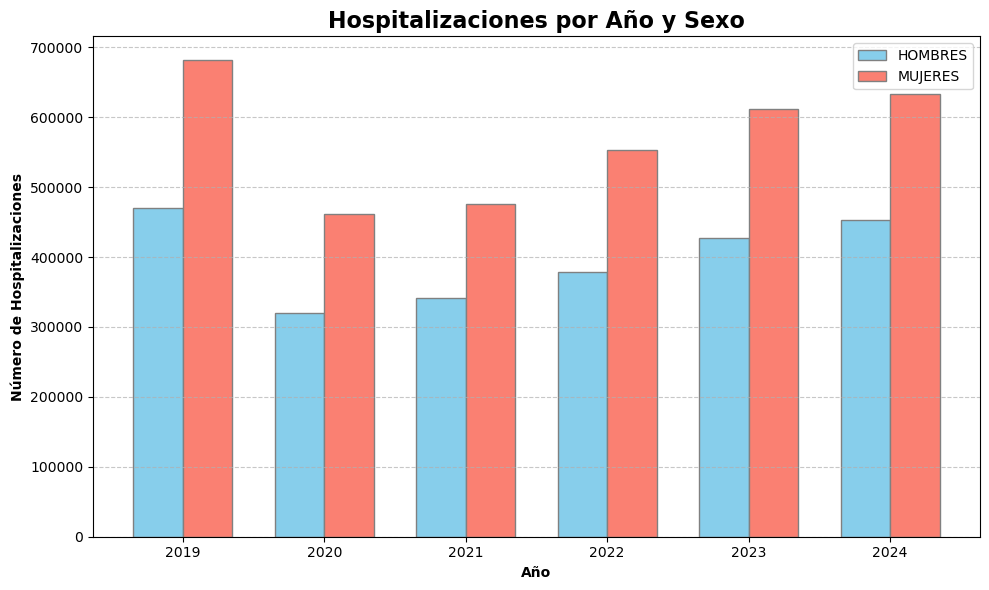

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

try:
    df_final = pd.read_csv('../1_data_processed/v0_base_de_datos_unificada.csv')

    # Agrupar por 'AÑO_ARCHIVO' y 'SEXO', y contar las filas
    df_conteo_anual_sexo = df_final.groupby(['AÑO_ARCHIVO', 'SEXO']).size().reset_index(name='COUNT')

    # Separar los datos por sexo para el gráfico
    hombres = df_conteo_anual_sexo[df_conteo_anual_sexo['SEXO'] == 'HOMBRE']
    mujeres = df_conteo_anual_sexo[df_conteo_anual_sexo['SEXO'] == 'MUJER']
    
    
    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    
    # Ancho de las barras
    bar_width = 0.35
    
    # Posiciones de las barras en el eje X
    r1 = hombres['AÑO_ARCHIVO'] - bar_width/2
    r2 = mujeres['AÑO_ARCHIVO'] + bar_width/2
    
    # Graficar las barras
    plt.bar(r1, hombres['COUNT'], color='skyblue', width=bar_width, edgecolor='grey', label='HOMBRES')
    plt.bar(r2, mujeres['COUNT'], color='salmon', width=bar_width, edgecolor='grey', label='MUJERES')

    # Configuración del gráfico
    plt.xlabel('Año', fontweight='bold')
    plt.ylabel('Número de Hospitalizaciones', fontweight='bold')
    plt.title('Hospitalizaciones por Año y Sexo', fontweight='bold', fontsize=16)
    plt.xticks(hombres['AÑO_ARCHIVO'])
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Guardar el gráfico como una imagen
    plt.tight_layout()
    plt.savefig('../5_results/figures/v0_hospitalizaciones_anuales_por_sexo.png')
    
    print("Gráfico de barras guardado en carpeta Results.")

except FileNotFoundError:
    print("Error: No se encontró 'v0_base_de_datos_unificada.csv'.")
except Exception as e:
    print(f"Ocurrió un error inesperado al generar el gráfico: {str(e)}")

## Top de Hospitales según número de pacientes

C:\Users\pkspl\AppData\Local\Temp\ipykernel_86684\2837906762.py:5: DtypeWarning: Columns (1,24,25,26,27,28,29,30,31,32,33,37,41,43,47,51,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,101,103,105,106,113,119,123,124,126,127,128) have mixed types. Specify dtype option on import or set low_memory=False.
  df_final = pd.read_csv('../1_data_processed/v0_base_de_datos_unificada.csv')


Error: No se encontró 'v0_base_de_datos_unificada.csv'.


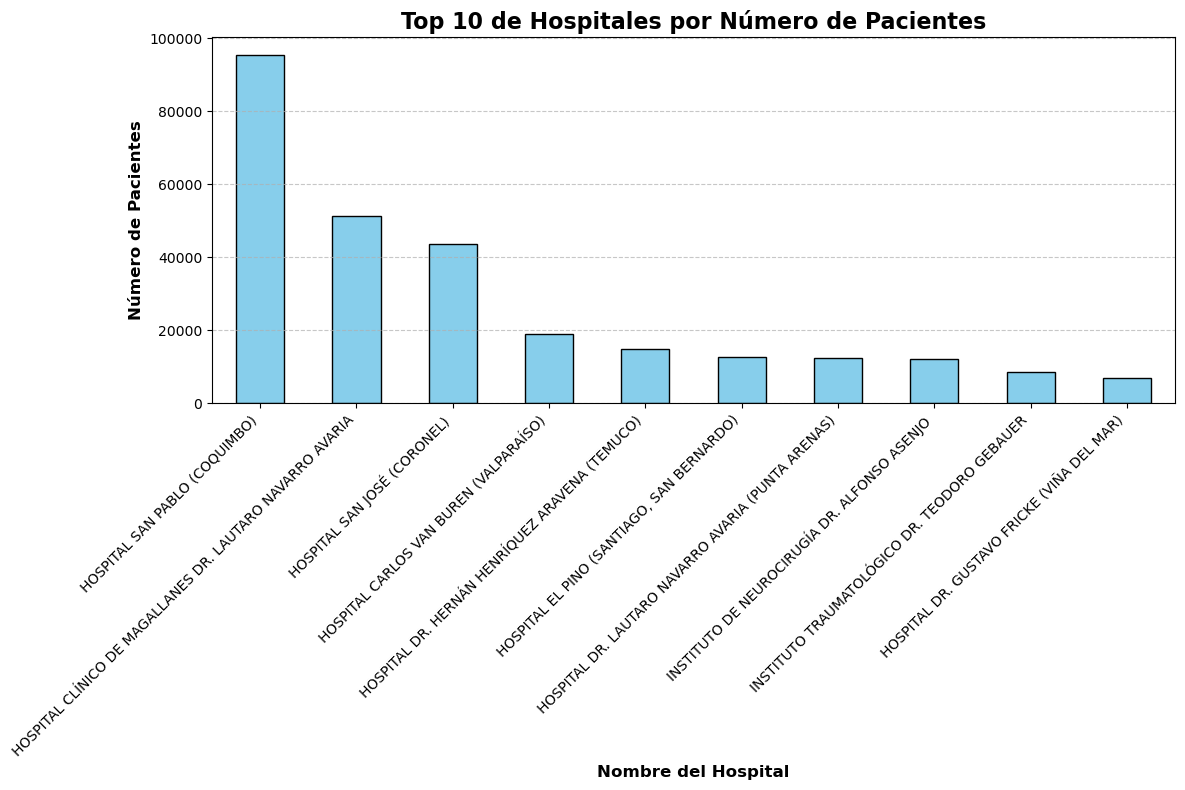

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    df_final = pd.read_csv('../1_data_processed/v0_base_de_datos_unificada.csv')

    # Contar los pacientes por hospital y obtener el top 10
    top_hospitales = df_final['HOSPPROCEDENCIA'].value_counts().nlargest(10)

    # Crear el gráfico de barras
    plt.figure(figsize=(12, 8))
    top_hospitales.plot(kind='bar', color='skyblue', edgecolor='black')

    # Configuración del gráfico
    plt.title('Top 10 de Hospitales por Número de Pacientes', fontsize=16, fontweight='bold')
    plt.xlabel('Nombre del Hospital', fontsize=12, fontweight='bold')
    plt.ylabel('Número de Pacientes', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')  # Rotar etiquetas para mejor legibilidad
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Guardar el gráfico como una imagen
    plt.savefig('../5_results/v0_top_10_hospitales.png')
    print("Gráfico de Top 10 de Hospitales guardado en carpeta Results'.")

except FileNotFoundError:
    print("Error: No se encontró 'v0_base_de_datos_unificada.csv'.")
except Exception as e:
    print(f"Ocurrió un error inesperado al generar el gráfico: {str(e)}")